In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import cifar10

# Carregamento dos dados
## CIFAR-10: 60.000 imagens coloridas (32x32x3), 10 classes
- x_train: imagens de treino
- y_train: rótulos do treino (inteiros 0..9)
- x_test: imagens de teste
- y_test: rótulos de teste

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

## Remover uma dimensão redundante de y

In [10]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## Confere os shapes

In [11]:
print("Shapes")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

Shapes
x_train: (50000, 32, 32, 3) y_train: (50000,)
x_test: (10000, 32, 32, 3) y_test: (10000,)


## Visualização

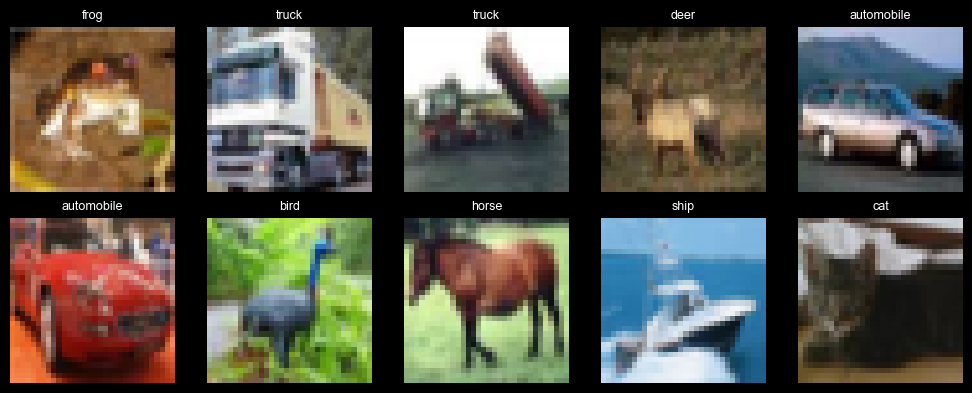

In [13]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Pré-processamento

In [14]:
x_train = x_train.astype("float32") / 255.0
y_test = x_test.astype("float32") / 255.0


## Conferência

In [15]:
print("Intervalo dos pixels (treino): ", x_train.min(), "a", x_train.max())

Intervalo dos pixels (treino):  0.0 a 1.0


## Definição do nosso modelo CNN

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 4096)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

## Compilação do Modelo

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Treinamento

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
352/352 - 23s - loss: 1.5535 - accuracy: 0.4466 - val_loss: 1.2740 - val_accuracy: 0.5526 - 23s/epoch - 64ms/step
Epoch 2/10
